In [138]:
import pandas as pd
import seaborn as sns

# Study Case 1: Cleaning Data Film IMBD

In [139]:
movies = pd.read_csv("IMDB_Movies.csv")

movies

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5038,Color,Scott Smith,1.0,87.0,2.0,318.0,Daphne Zuniga,637.0,NaN,Comedy|Drama,...,6,English,Canada,NaN,NaN,2013.0,470.0,7.7,NaN,84
5039,Color,NaN,43.0,43.0,NaN,319.0,Valorie Curry,841.0,NaN,Crime|Drama|Mystery|Thriller,...,359,English,USA,TV-14,NaN,NaN,593.0,7.5,16.00,32000
5040,Color,Benjamin Roberds,13.0,76.0,0.0,0.0,Maxwell Moody,0.0,NaN,Drama|Horror|Thriller,...,3,English,USA,NaN,1400.0,2013.0,0.0,6.3,NaN,16
5041,Color,Daniel Hsia,14.0,100.0,0.0,489.0,Daniel Henney,946.0,10443.0,Comedy|Drama|Romance,...,9,English,USA,PG-13,NaN,2012.0,719.0,6.3,2.35,660


Columns to drop:

-  color
-  director_facebook_likes
-  actor_1_facebook_likes
-  actor_2_facebook_likes
-  actor_3_facebook_likes
-  actor_2_name
-  cast_total_facebook_likes
-  actor_3_name
-  duration
-  facenumber_in_poster
-  content_rating
-  country
-  movie_imdb_link
-  aspect_ratio
-  plot_keywords

In [140]:
column_drop = {
    "color",
    "director_facebook_likes",
    "actor_1_facebook_likes",
    "actor_2_facebook_likes",
    "actor_3_facebook_likes",
    "actor_2_name",
    "cast_total_facebook_likes",
    "actor_3_name",
    "duration",
    "facenumber_in_poster",
    "content_rating",
    "country",
    "movie_imdb_link",
    "aspect_ratio",
    "plot_keywords"
}

if column_drop.issubset(movies.columns):
    movies = movies.drop(list(column_drop), axis=1)

movies


,director_name,num_critic_for_reviews,gross,genres,actor_1_name,movie_title,num_voted_users,num_user_for_reviews,language,budget,title_year,imdb_score,movie_facebook_likes
0,James Cameron,723.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,Avatar,886204,3054,English,237000000.0,2009.0,7.9,33000
1,Gore Verbinski,302.0,309404152.0,Action|Adventure|Fantasy,Johnny Depp,Pirates of the Caribbean: At World's End,471220,1238,English,300000000.0,2007.0,7.1,0
2,Sam Mendes,602.0,200074175.0,Action|Adventure|Thriller,Christoph Waltz,Spectre,275868,994,English,245000000.0,2015.0,6.8,85000
3,Christopher Nolan,813.0,448130642.0,Action|Thriller,Tom Hardy,The Dark Knight Rises,1144337,2701,English,250000000.0,2012.0,8.5,164000
4,Doug Walker,NaN,NaN,Documentary,Doug Walker,Star Wars: Episode VII - The Force Awakens ...,8,,NaN,NaN,NaN,7.1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5038,Scott Smith,1.0,NaN,Comedy|Drama,Eric Mabius,Signed Sealed Delivered,629,6,English,NaN,2013.0,7.7,84
5039,NaN,43.0,NaN,Crime|Drama|Mystery|Thriller,Natalie Zea,The Following,73839,359,English,NaN,NaN,7.5,32000
5040,Benjamin Roberds,13.0,NaN,Drama|Horror|Thriller,Eva Boehnke,A Plague So Pleasant,38,3,English,1400.0,2013.0,6.3,16
5041,Daniel Hsia,14.0,10443.0,Comedy|Drama|Romance,Alan Ruck,Shanghai Calling,1255,9,English,NaN,2012.0,6.3,660


In [141]:
movies.isnull().sum().sort_values(ascending=False)/len(movies)*100

gross                     17.529248
budget                     9.756098
title_year                 2.141582
director_name              2.062265
num_critic_for_reviews     0.991473
num_user_for_reviews       0.396589
language                   0.277613
actor_1_name               0.138806
genres                     0.000000
movie_title                0.000000
num_voted_users            0.000000
imdb_score                 0.000000
movie_facebook_likes       0.000000
dtype: float64

In [142]:
#  based on the previous code, I want to retrieve columns with null values
# first, store the result in a variable
movie_null_columns = movies.isnull().sum().sort_values(ascending=False)/len(movies)*100

# select by > 0 and convert into list
# store back into the same variable as it's unused
movie_null_columns = list(movie_null_columns[movie_null_columns > 0].index)

movie_null_columns

['gross',
 'budget',
 'title_year',
 'director_name',
 'num_critic_for_reviews',
 'num_user_for_reviews',
 'language',
 'actor_1_name']

In [143]:
movies[movie_null_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gross                   4159 non-null   float64
 1   budget                  4551 non-null   float64
 2   title_year              4935 non-null   float64
 3   director_name           4939 non-null   object 
 4   num_critic_for_reviews  4993 non-null   float64
 5   num_user_for_reviews    5023 non-null   object 
 6   language                5029 non-null   object 
 7   actor_1_name            5036 non-null   object 
dtypes: float64(4), object(4)
memory usage: 315.3+ KB


- Jika kolom tersebut bertipe numeric, impute dengan nilai statistik yang representatif. Visualisasikan distribusi data pada kolom numeric untuk melihat apakah imputasi dapat dilakukan dengan mean. [ref](https://vitalflux.com/pandas-impute-missing-values-mean-median-mode/)
    - Jika distribusinya skewed akan dilakukan imputasi dengan median.
    - Jika distribusinya normal akan dilakukan imputasi dengan mean.
- Jika kolom tersebut bertipe object, impute dengan nilai "unknown"


### Gross

<Axes: xlabel='gross', ylabel='Count'>

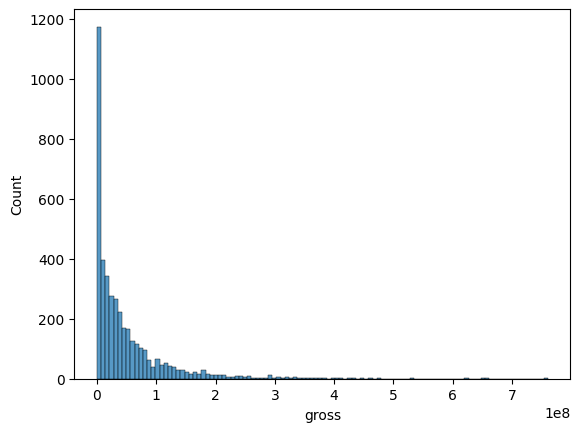

In [144]:
# histogram for plotting gross

sns.histplot(data=movies, x="gross")

In [145]:
# since the gross column has skewed distribution (a negative one), then we impute 
# the missing value with its median
movies.gross = movies.gross.fillna(movies.gross.median())

# check if there's  any null value
movies.gross.notna().all()

np.True_

### Budget

<Axes: xlabel='budget', ylabel='Count'>

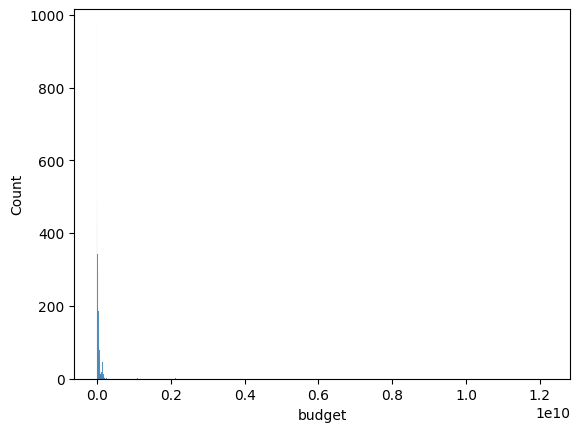

In [146]:
# histogram for plotting budget

sns.histplot(data=movies, x="budget")

In [147]:
movies.budget = movies.budget.fillna(movies.budget.median())

movies.budget.notna().all()

np.True_

<Axes: xlabel='budget', ylabel='Count'>

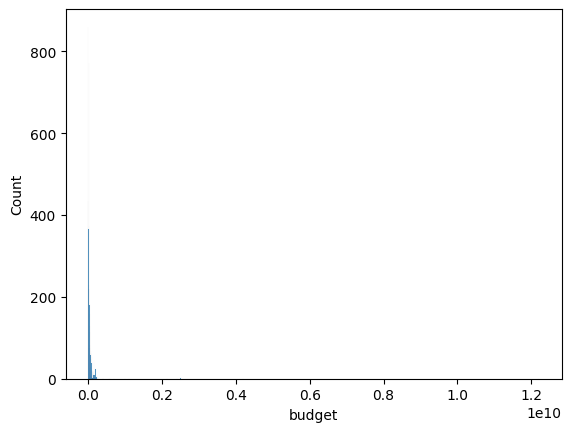

In [148]:
sns.histplot(data=movies, x="budget")

In [149]:
# Identifikasi data duplikat

movies[movies.duplicated(keep=False)].sort_values(by=["director_name"])

,director_name,num_critic_for_reviews,gross,genres,actor_1_name,movie_title,num_voted_users,num_user_for_reviews,language,budget,title_year,imdb_score,movie_facebook_likes
1096,Albert Hughes,208.0,31598308.0,Horror|Mystery|Thriller,Johnny Depp,From Hell,124765,541,English,35000000.0,2001.0,6.8,0
1449,Albert Hughes,208.0,31598308.0,Horror|Mystery|Thriller,Johnny Depp,From Hell,124765,541,English,35000000.0,2001.0,6.8,0
2063,Andy Cadiff,65.0,12189514.0,Comedy|Romance,Annabella Sciorra,Chasing Liberty,30092,129,English,23000000.0,2004.0,6.1,0
1705,Andy Cadiff,65.0,12189514.0,Comedy|Romance,Annabella Sciorra,Chasing Liberty,30092,129,English,23000000.0,2004.0,6.1,0
663,Angelina Jolie Pitt,322.0,115603980.0,Biography|Drama|Sport|War,Finn Wittrock,Unbroken,103589,351,English,65000000.0,2014.0,7.2,35000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1171,Yimou Zhang,283.0,84961.0,Action|Adventure|History,Jet Li,Hero,149414,841,Mandarin,31000000.0,2002.0,7.9,0
4408,Yimou Zhang,101.0,190666.0,Comedy|Drama,Honglei Sun,"A Woman, a Gun and a Noodle Shop",2410,20,Mandarin,20000000.0,2009.0,5.7,784
3007,Yimou Zhang,101.0,190666.0,Comedy|Drama,Honglei Sun,"A Woman, a Gun and a Noodle Shop",2410,20,Mandarin,20000000.0,2009.0,5.7,784
3800,NaN,9.0,25517500.0,Drama|Fantasy,Holly Hunter,Saving Grace,3852,47,English,20000000.0,NaN,7.5,634


In [150]:
# Hapus semua data ganda

movies.drop_duplicates(keep='first', inplace=True, ignore_index=True)

movies

,director_name,num_critic_for_reviews,gross,genres,actor_1_name,movie_title,num_voted_users,num_user_for_reviews,language,budget,title_year,imdb_score,movie_facebook_likes
0,James Cameron,723.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,Avatar,886204,3054,English,237000000.0,2009.0,7.9,33000
1,Gore Verbinski,302.0,309404152.0,Action|Adventure|Fantasy,Johnny Depp,Pirates of the Caribbean: At World's End,471220,1238,English,300000000.0,2007.0,7.1,0
2,Sam Mendes,602.0,200074175.0,Action|Adventure|Thriller,Christoph Waltz,Spectre,275868,994,English,245000000.0,2015.0,6.8,85000
3,Christopher Nolan,813.0,448130642.0,Action|Thriller,Tom Hardy,The Dark Knight Rises,1144337,2701,English,250000000.0,2012.0,8.5,164000
4,Doug Walker,NaN,25517500.0,Documentary,Doug Walker,Star Wars: Episode VII - The Force Awakens ...,8,,NaN,20000000.0,NaN,7.1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4991,Scott Smith,1.0,25517500.0,Comedy|Drama,Eric Mabius,Signed Sealed Delivered,629,6,English,20000000.0,2013.0,7.7,84
4992,NaN,43.0,25517500.0,Crime|Drama|Mystery|Thriller,Natalie Zea,The Following,73839,359,English,20000000.0,NaN,7.5,32000
4993,Benjamin Roberds,13.0,25517500.0,Drama|Horror|Thriller,Eva Boehnke,A Plague So Pleasant,38,3,English,1400.0,2013.0,6.3,16
4994,Daniel Hsia,14.0,10443.0,Comedy|Drama|Romance,Alan Ruck,Shanghai Calling,1255,9,English,20000000.0,2012.0,6.3,660


In [151]:
# Hapus data tergolong outlier

movies.describe()

,num_critic_for_reviews,gross,num_voted_users,budget,title_year,imdb_score,movie_facebook_likes
count,4947.000000,4.996000e+03,4.996000e+03,4.996000e+03,4889.000000,4996.000000,4996.000000
mean,139.931474,4.434739e+07,8.349716e+04,3.783019e+07,2002.465944,6.441513,7490.292034
std,121.483433,6.235101e+07,1.381073e+05,1.967513e+08,12.476480,1.123986,19294.056488
min,1.000000,1.620000e+02,5.000000e+00,2.180000e+02,1916.000000,1.600000,0.000000
25%,50.000000,8.377002e+06,8.560000e+03,7.000000e+06,1999.000000,5.800000,0.000000
50%,110.000000,2.551750e+07,3.430050e+04,2.000000e+07,2005.000000,6.600000,162.500000
75%,195.000000,5.140538e+07,9.615500e+04,4.000000e+07,2011.000000,7.200000,3000.000000
max,813.000000,7.605058e+08,1.689764e+06,1.221550e+10,2016.000000,9.500000,349000.000000


In [152]:
# Movie dengan gross tertinggi

movies[movies['gross'] == movies.gross.max()]

,director_name,num_critic_for_reviews,gross,genres,actor_1_name,movie_title,num_voted_users,num_user_for_reviews,language,budget,title_year,imdb_score,movie_facebook_likes
0,James Cameron,723.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,CCH Pounder,Avatar,886204,3054,English,237000000.0,2009.0,7.9,33000


In [153]:
# Movie dengan budget tertinggi

movies[movies.budget == movies.budget.max()]

,director_name,num_critic_for_reviews,gross,genres,actor_1_name,movie_title,num_voted_users,num_user_for_reviews,language,budget,title_year,imdb_score,movie_facebook_likes
2962,Joon-ho Bong,363.0,2201412.0,Comedy|Drama|Horror|Sci-Fi,Doona Bae,The Host,68883,279,Korean,1.221550e+10,2006.0,7.0,7000


In [154]:
# Apply +- 1.5 IQR

q1_budget = movies.budget.quantile(0.25)
q3_budget = movies.budget.quantile(0.75)
iqr_budget = q3_budget - q1_budget
lower_bound = max(q1_budget - 1.5 * iqr_budget, 0)
upper_bound = q3_budget + 1.5 * iqr_budget

lower_rule = movies.budget > lower_bound
upper_rule = movies.budget < upper_bound

movies[lower_rule & upper_rule]

,director_name,num_critic_for_reviews,gross,genres,actor_1_name,movie_title,num_voted_users,num_user_for_reviews,language,budget,title_year,imdb_score,movie_facebook_likes
4,Doug Walker,NaN,25517500.0,Documentary,Doug Walker,Star Wars: Episode VII - The Force Awakens ...,8,,NaN,20000000.0,NaN,7.1,0
55,Peter Sohn,298.0,123070338.0,Adventure|Animation|Comedy|Family|Fantasy,A.J. Buckley,The Good Dinosaur,62836,345,English,20000000.0,2015.0,6.8,20000
84,Roland Joffé,10.0,25517500.0,Action|Adventure|Romance|Sci-Fi,Tamsin Egerton,The Lovers,2138,15,English,20000000.0,2015.0,4.5,677
98,Hideaki Anno,1.0,25517500.0,Action|Adventure|Drama|Horror|Sci-Fi,Mark Chinnery,Godzilla Resurgence,374,13,Japanese,20000000.0,2016.0,8.2,0
100,Rob Cohen,187.0,144512310.0,Action|Crime|Thriller,Paul Walker,The Fast and the Furious,272223,988,English,38000000.0,2001.0,6.7,14000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4991,Scott Smith,1.0,25517500.0,Comedy|Drama,Eric Mabius,Signed Sealed Delivered,629,6,English,20000000.0,2013.0,7.7,84
4992,NaN,43.0,25517500.0,Crime|Drama|Mystery|Thriller,Natalie Zea,The Following,73839,359,English,20000000.0,NaN,7.5,32000
4993,Benjamin Roberds,13.0,25517500.0,Drama|Horror|Thriller,Eva Boehnke,A Plague So Pleasant,38,3,English,1400.0,2013.0,6.3,16
4994,Daniel Hsia,14.0,10443.0,Comedy|Drama|Romance,Alan Ruck,Shanghai Calling,1255,9,English,20000000.0,2012.0,6.3,660


# Study Case 2: Cleaning Cars Data

In [155]:
# read data from autos.csv

cars = pd.read_csv("autos.csv")

cars

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,2016-03-26 17:47:46,Peugeot_807_160_NAVTECH_ON_BOARD,privat,Angebot,"$5,000",control,bus,2004,manuell,158,andere,"150,000km",3,lpg,peugeot,nein,2016-03-26 00:00:00,0,79588,2016-04-06 06:45:54
1,2016-04-04 13:38:56,BMW_740i_4_4_Liter_HAMANN_UMBAU_Mega_Optik,privat,Angebot,"$8,500",control,limousine,1997,automatik,286,7er,"150,000km",6,benzin,bmw,nein,2016-04-04 00:00:00,0,71034,2016-04-06 14:45:08
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,privat,Angebot,"$8,990",test,limousine,2009,manuell,102,golf,"70,000km",7,benzin,volkswagen,nein,2016-03-26 00:00:00,0,35394,2016-04-06 20:15:37
3,2016-03-12 16:58:10,Smart_smart_fortwo_coupe_softouch/F1/Klima/Pan...,privat,Angebot,"$4,350",control,kleinwagen,2007,automatik,71,fortwo,"70,000km",6,benzin,smart,nein,2016-03-12 00:00:00,0,33729,2016-03-15 03:16:28
4,2016-04-01 14:38:50,Ford_Focus_1_6_Benzin_TÜV_neu_ist_sehr_gepfleg...,privat,Angebot,"$1,350",test,kombi,2003,manuell,0,focus,"150,000km",7,benzin,ford,nein,2016-04-01 00:00:00,0,39218,2016-04-01 14:38:50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2016-03-27 14:38:19,Audi_Q5_3.0_TDI_qu._S_tr.__Navi__Panorama__Xenon,privat,Angebot,"$24,900",control,limousine,2011,automatik,239,q5,"100,000km",1,diesel,audi,nein,2016-03-27 00:00:00,0,82131,2016-04-01 13:47:40
49996,2016-03-28 10:50:25,Opel_Astra_F_Cabrio_Bertone_Edition___TÜV_neu+...,privat,Angebot,"$1,980",control,cabrio,1996,manuell,75,astra,"150,000km",5,benzin,opel,nein,2016-03-28 00:00:00,0,44807,2016-04-02 14:18:02
49997,2016-04-02 14:44:48,Fiat_500_C_1.2_Dualogic_Lounge,privat,Angebot,"$13,200",test,cabrio,2014,automatik,69,500,"5,000km",11,benzin,fiat,nein,2016-04-02 00:00:00,0,73430,2016-04-04 11:47:27
49998,2016-03-08 19:25:42,Audi_A3_2.0_TDI_Sportback_Ambition,privat,Angebot,"$22,900",control,kombi,2013,manuell,150,a3,"40,000km",11,diesel,audi,nein,2016-03-08 00:00:00,0,35683,2016-04-05 16:45:07


In [156]:
# inspect using info()

cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   dateCrawled          50000 non-null  object
 1   name                 50000 non-null  object
 2   seller               50000 non-null  object
 3   offerType            50000 non-null  object
 4   price                50000 non-null  object
 5   abtest               50000 non-null  object
 6   vehicleType          44905 non-null  object
 7   yearOfRegistration   50000 non-null  int64 
 8   gearbox              47320 non-null  object
 9   powerPS              50000 non-null  int64 
 10  model                47242 non-null  object
 11  odometer             50000 non-null  object
 12  monthOfRegistration  50000 non-null  int64 
 13  fuelType             45518 non-null  object
 14  brand                50000 non-null  object
 15  notRepairedDamage    40171 non-null  object
 16  date

In [157]:
# inspect using describe()

cars.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
dateCrawled,50000,48213,2016-03-23 18:39:34,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,50000,38754,Ford_Fiesta,78,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller,50000,2,privat,49999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
offerType,50000,2,Angebot,49999,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,50000,2357,$0,1421,NaN,NaN,NaN,NaN,NaN,NaN,NaN
abtest,50000,2,test,25756,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vehicleType,44905,8,limousine,12859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
yearOfRegistration,50000.0,NaN,NaN,NaN,2005.07328,105.712813,1000.0,1999.0,2003.0,2008.0,9999.0
gearbox,47320,2,manuell,36993,NaN,NaN,NaN,NaN,NaN,NaN,NaN
powerPS,50000.0,NaN,NaN,NaN,116.35592,209.216627,0.0,70.0,105.0,150.0,17700.0


In [158]:
# remove seller, offerType, and nrOfPictures columns

column_to_remove = ['seller', 'offerType', 'nrOfPictures']

for name in column_to_remove:
    if name in cars:
        del cars[name]

cars.head()

,dateCrawled,name,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,postalCode,lastSeen
0,2016-03-26 17:47:46,Peugeot_807_160_NAVTECH_ON_BOARD,"$5,000",control,bus,2004,manuell,158,andere,"150,000km",3,lpg,peugeot,nein,2016-03-26 00:00:00,79588,2016-04-06 06:45:54
1,2016-04-04 13:38:56,BMW_740i_4_4_Liter_HAMANN_UMBAU_Mega_Optik,"$8,500",control,limousine,1997,automatik,286,7er,"150,000km",6,benzin,bmw,nein,2016-04-04 00:00:00,71034,2016-04-06 14:45:08
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,"$8,990",test,limousine,2009,manuell,102,golf,"70,000km",7,benzin,volkswagen,nein,2016-03-26 00:00:00,35394,2016-04-06 20:15:37
3,2016-03-12 16:58:10,Smart_smart_fortwo_coupe_softouch/F1/Klima/Pan...,"$4,350",control,kleinwagen,2007,automatik,71,fortwo,"70,000km",6,benzin,smart,nein,2016-03-12 00:00:00,33729,2016-03-15 03:16:28
4,2016-04-01 14:38:50,Ford_Focus_1_6_Benzin_TÜV_neu_ist_sehr_gepfleg...,"$1,350",test,kombi,2003,manuell,0,focus,"150,000km",7,benzin,ford,nein,2016-04-01 00:00:00,39218,2016-04-01 14:38:50


In [159]:
# rename column naming style from camelCase to snake_case

def snakeCaseConverter(originalName):
    res = ''.join(['_' + char.lower() if char.isupper() else char for char in originalName])
    if res.startswith('_'):
        res = res[1:]
    return res

new_column_dict = {}
for name in list(cars.columns):
    new_column_dict[name] = snakeCaseConverter(name)

cars.rename(columns=new_column_dict, inplace=True)

cars.head()


,date_crawled,name,price,abtest,vehicle_type,year_of_registration,gearbox,power_p_s,model,odometer,month_of_registration,fuel_type,brand,not_repaired_damage,date_created,postal_code,last_seen
0,2016-03-26 17:47:46,Peugeot_807_160_NAVTECH_ON_BOARD,"$5,000",control,bus,2004,manuell,158,andere,"150,000km",3,lpg,peugeot,nein,2016-03-26 00:00:00,79588,2016-04-06 06:45:54
1,2016-04-04 13:38:56,BMW_740i_4_4_Liter_HAMANN_UMBAU_Mega_Optik,"$8,500",control,limousine,1997,automatik,286,7er,"150,000km",6,benzin,bmw,nein,2016-04-04 00:00:00,71034,2016-04-06 14:45:08
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,"$8,990",test,limousine,2009,manuell,102,golf,"70,000km",7,benzin,volkswagen,nein,2016-03-26 00:00:00,35394,2016-04-06 20:15:37
3,2016-03-12 16:58:10,Smart_smart_fortwo_coupe_softouch/F1/Klima/Pan...,"$4,350",control,kleinwagen,2007,automatik,71,fortwo,"70,000km",6,benzin,smart,nein,2016-03-12 00:00:00,33729,2016-03-15 03:16:28
4,2016-04-01 14:38:50,Ford_Focus_1_6_Benzin_TÜV_neu_ist_sehr_gepfleg...,"$1,350",test,kombi,2003,manuell,0,focus,"150,000km",7,benzin,ford,nein,2016-04-01 00:00:00,39218,2016-04-01 14:38:50


In [160]:
# convert the values in German to English

mapping_dict_gearbox = {
    'manuell' : 'manually',
    'automatik' : 'automatic'
}
mapping_dict_fuel = {  
    'lpg' : 'lpg',
    'benzin' : 'gasoline',
    'diesel' : 'diesel',
    'cng' : 'cng',
    'hybrid' : 'hybrid',
    'elektro' : 'elektro',
    'andere' : 'other'
}
mapping_dict_damage = {
    'nein' : 'no',
    'ja' : 'yes'
}
cars.replace({'gearbox': mapping_dict_gearbox}, inplace=True)
cars.replace({'fuel_type': mapping_dict_fuel}, inplace=True)
cars.replace({'not_repaired_damage': mapping_dict_damage}, inplace=True)

cars.head()

,date_crawled,name,price,abtest,vehicle_type,year_of_registration,gearbox,power_p_s,model,odometer,month_of_registration,fuel_type,brand,not_repaired_damage,date_created,postal_code,last_seen
0,2016-03-26 17:47:46,Peugeot_807_160_NAVTECH_ON_BOARD,"$5,000",control,bus,2004,manually,158,andere,"150,000km",3,lpg,peugeot,no,2016-03-26 00:00:00,79588,2016-04-06 06:45:54
1,2016-04-04 13:38:56,BMW_740i_4_4_Liter_HAMANN_UMBAU_Mega_Optik,"$8,500",control,limousine,1997,automatic,286,7er,"150,000km",6,gasoline,bmw,no,2016-04-04 00:00:00,71034,2016-04-06 14:45:08
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,"$8,990",test,limousine,2009,manually,102,golf,"70,000km",7,gasoline,volkswagen,no,2016-03-26 00:00:00,35394,2016-04-06 20:15:37
3,2016-03-12 16:58:10,Smart_smart_fortwo_coupe_softouch/F1/Klima/Pan...,"$4,350",control,kleinwagen,2007,automatic,71,fortwo,"70,000km",6,gasoline,smart,no,2016-03-12 00:00:00,33729,2016-03-15 03:16:28
4,2016-04-01 14:38:50,Ford_Focus_1_6_Benzin_TÜV_neu_ist_sehr_gepfleg...,"$1,350",test,kombi,2003,manually,0,focus,"150,000km",7,gasoline,ford,no,2016-04-01 00:00:00,39218,2016-04-01 14:38:50


In [161]:
# detect and impute missing values

# detect columns that have missing values
column_nan = cars.isna().sum()
column_nan = list(column_nan[column_nan > 0].index)

In [162]:
# get info about the columns

cars[column_nan].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   vehicle_type         44905 non-null  object
 1   gearbox              47320 non-null  object
 2   model                47242 non-null  object
 3   fuel_type            45518 non-null  object
 4   not_repaired_damage  40171 non-null  object
dtypes: object(5)
memory usage: 1.9+ MB


In [163]:
# replace missing value using the mode value on each column

for col in column_nan:
    mode_value = cars[col].mode()[0]
    cars[col] = cars[col].fillna(value=mode_value)

cars.head()

,date_crawled,name,price,abtest,vehicle_type,year_of_registration,gearbox,power_p_s,model,odometer,month_of_registration,fuel_type,brand,not_repaired_damage,date_created,postal_code,last_seen
0,2016-03-26 17:47:46,Peugeot_807_160_NAVTECH_ON_BOARD,"$5,000",control,bus,2004,manually,158,andere,"150,000km",3,lpg,peugeot,no,2016-03-26 00:00:00,79588,2016-04-06 06:45:54
1,2016-04-04 13:38:56,BMW_740i_4_4_Liter_HAMANN_UMBAU_Mega_Optik,"$8,500",control,limousine,1997,automatic,286,7er,"150,000km",6,gasoline,bmw,no,2016-04-04 00:00:00,71034,2016-04-06 14:45:08
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,"$8,990",test,limousine,2009,manually,102,golf,"70,000km",7,gasoline,volkswagen,no,2016-03-26 00:00:00,35394,2016-04-06 20:15:37
3,2016-03-12 16:58:10,Smart_smart_fortwo_coupe_softouch/F1/Klima/Pan...,"$4,350",control,kleinwagen,2007,automatic,71,fortwo,"70,000km",6,gasoline,smart,no,2016-03-12 00:00:00,33729,2016-03-15 03:16:28
4,2016-04-01 14:38:50,Ford_Focus_1_6_Benzin_TÜV_neu_ist_sehr_gepfleg...,"$1,350",test,kombi,2003,manually,0,focus,"150,000km",7,gasoline,ford,no,2016-04-01 00:00:00,39218,2016-04-01 14:38:50


In [164]:
# check if there's still missing values

cars.isna().sum()

date_crawled             0
name                     0
price                    0
abtest                   0
vehicle_type             0
year_of_registration     0
gearbox                  0
power_p_s                0
model                    0
odometer                 0
month_of_registration    0
fuel_type                0
brand                    0
not_repaired_damage      0
date_created             0
postal_code              0
last_seen                0
dtype: int64

In [119]:
# check cars info

cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   date_crawled           50000 non-null  object
 1   name                   50000 non-null  object
 2   price                  50000 non-null  object
 3   abtest                 50000 non-null  object
 4   vehicle_type           50000 non-null  object
 5   year_of_registration   50000 non-null  int64 
 6   gearbox                50000 non-null  object
 7   power_p_s              50000 non-null  int64 
 8   model                  50000 non-null  object
 9   odometer               50000 non-null  object
 10  month_of_registration  50000 non-null  int64 
 11  fuel_type              50000 non-null  object
 12  brand                  50000 non-null  object
 13  not_repaired_damage    50000 non-null  object
 14  date_created           50000 non-null  object
 15  postal_code        

In [ ]:
# replace price values to int64

# new_values = []
# for value in cars['price'].values:
#     new_val = int(value.replace('$', '').replace(',', ''))
#     new_values.append(new_val)

# cars['price'] = pd.Series(new_values)

cars["price"] = cars["price"].str.replace("$", "")
cars["price"] = cars["price"].str.replace("$", "")
cars["price"] = cars["price"].astype(int)

cars.head()

,date_crawled,name,price,abtest,vehicle_type,year_of_registration,gearbox,power_p_s,model,odometer,month_of_registration,fuel_type,brand,not_repaired_damage,date_created,postal_code,last_seen
0,2016-03-26 17:47:46,Peugeot_807_160_NAVTECH_ON_BOARD,5000,control,bus,2004,manually,158,andere,"150,000km",3,lpg,peugeot,no,2016-03-26 00:00:00,79588,2016-04-06 06:45:54
1,2016-04-04 13:38:56,BMW_740i_4_4_Liter_HAMANN_UMBAU_Mega_Optik,8500,control,limousine,1997,automatic,286,7er,"150,000km",6,gasoline,bmw,no,2016-04-04 00:00:00,71034,2016-04-06 14:45:08
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,8990,test,limousine,2009,manually,102,golf,"70,000km",7,gasoline,volkswagen,no,2016-03-26 00:00:00,35394,2016-04-06 20:15:37
3,2016-03-12 16:58:10,Smart_smart_fortwo_coupe_softouch/F1/Klima/Pan...,4350,control,kleinwagen,2007,automatic,71,fortwo,"70,000km",6,gasoline,smart,no,2016-03-12 00:00:00,33729,2016-03-15 03:16:28
4,2016-04-01 14:38:50,Ford_Focus_1_6_Benzin_TÜV_neu_ist_sehr_gepfleg...,1350,test,kombi,2003,manually,0,focus,"150,000km",7,gasoline,ford,no,2016-04-01 00:00:00,39218,2016-04-01 14:38:50


In [167]:
# replace odometer values to int64

new_values = []
for value in cars['odometer'].values:
    new_val = int(value.replace(',', '').replace('km', ''))
    new_values.append(new_val)

cars['odometer'] = pd.Series(new_values)

cars.head()

,date_crawled,name,price,abtest,vehicle_type,year_of_registration,gearbox,power_p_s,model,odometer,month_of_registration,fuel_type,brand,not_repaired_damage,date_created,postal_code,last_seen
0,2016-03-26 17:47:46,Peugeot_807_160_NAVTECH_ON_BOARD,5000,control,bus,2004,manually,158,andere,150000,3,lpg,peugeot,no,2016-03-26 00:00:00,79588,2016-04-06 06:45:54
1,2016-04-04 13:38:56,BMW_740i_4_4_Liter_HAMANN_UMBAU_Mega_Optik,8500,control,limousine,1997,automatic,286,7er,150000,6,gasoline,bmw,no,2016-04-04 00:00:00,71034,2016-04-06 14:45:08
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,8990,test,limousine,2009,manually,102,golf,70000,7,gasoline,volkswagen,no,2016-03-26 00:00:00,35394,2016-04-06 20:15:37
3,2016-03-12 16:58:10,Smart_smart_fortwo_coupe_softouch/F1/Klima/Pan...,4350,control,kleinwagen,2007,automatic,71,fortwo,70000,6,gasoline,smart,no,2016-03-12 00:00:00,33729,2016-03-15 03:16:28
4,2016-04-01 14:38:50,Ford_Focus_1_6_Benzin_TÜV_neu_ist_sehr_gepfleg...,1350,test,kombi,2003,manually,0,focus,150000,7,gasoline,ford,no,2016-04-01 00:00:00,39218,2016-04-01 14:38:50


In [168]:
# rename column odometer to odometer_km

cars.rename({'odometer': 'odometer_km'}, axis=1, inplace=True)

cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   date_crawled           50000 non-null  object
 1   name                   50000 non-null  object
 2   price                  50000 non-null  int64 
 3   abtest                 50000 non-null  object
 4   vehicle_type           50000 non-null  object
 5   year_of_registration   50000 non-null  int64 
 6   gearbox                50000 non-null  object
 7   power_p_s              50000 non-null  int64 
 8   model                  50000 non-null  object
 9   odometer_km            50000 non-null  int64 
 10  month_of_registration  50000 non-null  int64 
 11  fuel_type              50000 non-null  object
 12  brand                  50000 non-null  object
 13  not_repaired_damage    50000 non-null  object
 14  date_created           50000 non-null  object
 15  postal_code        